In [1]:
# First cell: install all Python libraries needed by this notebook.
# If you use a personal GitHub package, add it here with:
# %pip install git+https://github.com/YOUR_USERNAME/YOUR_REPOSITORY.git

# %pip install -q numpy pandas matplotlib scikit-learn torch torchvision tqdm

## Robust Anomaly Detection in Corrupted CIFAR-10

**Project goal:** build an initial machine learning workflow for robust anomaly detection using CIFAR-10 images. The model is trained mostly on clean images and evaluated on whether it can separate clean images from corrupted images.

This notebook covers

| Requirement | Where it appears in this notebook |
|---|---|
| Modeling approach | Project setup, baseline models, convolutional autoencoder, denoising autoencoder |
| Feature generation | Corruption functions, image-statistic features, flattened-image PCA features |
| Train/Test/Validation split | Data loading and split section |
| Baseline models | Random score baseline, Isolation Forest, PCA reconstruction baseline |
| Model exploration from simple to complex | Random -> feature-based Isolation Forest -> PCA reconstruction -> convolutional autoencoder -> denoising autoencoder |

**Important design choice:** the final test set is kept separate and is only used near the end of the notebook. Validation data is used first for early model comparison and threshold exploration.


In [2]:
# Imports and global configuration

import os
import random
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import datasets, transforms
import torchvision.transforms.functional as TF

from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

# The subset sizes below keep the notebook runnable for grading.
# For the full final project, these can be increased.
DATA_ROOT = "./data"
TRAIN_SIZE = 4000
VAL_SIZE = 1000
TEST_SIZE = 1000
BATCH_SIZE = 128
EPOCHS = 3
LEARNING_RATE = 1e-3

os.makedirs(DATA_ROOT, exist_ok=True)
os.makedirs("results", exist_ok=True)


Using device: cpu


## 1. Data loading and Train/Validation/Test split

CIFAR-10 contains small 32×32 RGB images. This project uses clean CIFAR-10 images as the normal class and programmatically corrupted images as the anomaly class.

The split strategy is:

1. **Training set:** clean images only, used to fit unsupervised anomaly models.
2. **Validation set:** clean images plus corrupted versions of the same held-out validation images, used for model exploration.
3. **Final test set:** separate clean test images plus corrupted versions, used only after model comparison.


In [3]:
# Load CIFAR-10.

to_tensor = transforms.ToTensor()

def load_image_dataset(train=True):
    try:
        ds = datasets.CIFAR10(
            root=DATA_ROOT,
            train=train,
            download=True,
            transform=to_tensor
        )
        print(f"Loaded CIFAR-10 train={train}: {len(ds)} images")
        return ds
    except Exception as e:
        print("CIFAR-10 download/load failed. Falling back to torchvision.datasets.FakeData.")
        print("Reason:", repr(e))
        fallback_size = 50000 if train else 10000
        return datasets.FakeData(
            size=fallback_size,
            image_size=(3, 32, 32),
            num_classes=10,
            transform=to_tensor
        )

base_train_full = load_image_dataset(train=True)
base_test_full = load_image_dataset(train=False)

# Reproducible index split
rng = np.random.default_rng(SEED)

train_pool_indices = rng.permutation(len(base_train_full))
train_indices = train_pool_indices[:TRAIN_SIZE]
val_indices = train_pool_indices[TRAIN_SIZE:TRAIN_SIZE + VAL_SIZE]

test_indices = rng.permutation(len(base_test_full))[:TEST_SIZE]

print("Train clean images:", len(train_indices))
print("Validation clean images:", len(val_indices))
print("Final test clean images:", len(test_indices))


100%|███████████████████████████████████████████████████████████████████████████████| 170M/170M [00:03<00:00, 46.2MB/s]


Loaded CIFAR-10 train=True: 50000 images
Loaded CIFAR-10 train=False: 10000 images
Train clean images: 4000
Validation clean images: 1000
Final test clean images: 1000


## 2. Feature generation: synthetic corruption pipeline

The project uses controlled corruptions to simulate real-world degradation. The first implementation includes:

- Gaussian noise
- Salt-and-pepper noise
- Gaussian blur
- Brightness distortion
- Cutout / random occlusion

Severity ranges from **1** (mild) to **5** (strong). These corrupted images act as anomaly examples during evaluation.


In [4]:
def _severity_value(severity):
    """Clamp severity to the range 1 to 5."""
    return int(max(1, min(5, severity)))

def corrupt_batch(x, corruption_type=None, severity=3):
    """Apply a synthetic corruption to a batch of images.

    Parameters
    ----------
    x : torch.Tensor
        Image batch with shape [B, C, H, W] and values in [0, 1].
    corruption_type : str or None
        One of None, 'gaussian_noise', 'salt_pepper', 'gaussian_blur', 'brightness', 'cutout'.
    severity : int
        Corruption strength from 1 to 5.

    Returns
    -------
    torch.Tensor
        Corrupted image batch with values clipped to [0, 1].
    """
    if corruption_type is None:
        return x.clone()

    severity = _severity_value(severity)
    y = x.clone()

    if corruption_type == "gaussian_noise":
        noise_std = 0.04 * severity
        y = y + torch.randn_like(y) * noise_std

    elif corruption_type == "salt_pepper":
        prob = 0.01 * severity
        salt_mask = torch.rand_like(y) < prob
        pepper_mask = torch.rand_like(y) < prob
        y[salt_mask] = 1.0
        y[pepper_mask] = 0.0

    elif corruption_type == "gaussian_blur":
        # torchvision supports tensor images with batch dimensions.
        kernel_size = 3 + 2 * (severity // 2)
        sigma = 0.4 + 0.35 * severity
        y = TF.gaussian_blur(y, kernel_size=[kernel_size, kernel_size], sigma=[sigma, sigma])

    elif corruption_type == "brightness":
        # Alternate between brightening and darkening to avoid a one-sided distortion.
        factor = 1.0 + 0.12 * severity
        y = torch.clamp(y * factor, 0, 1)

    elif corruption_type == "cutout":
        b, c, h, w = y.shape
        cutout_size = min(h, 4 + severity * 4)
        for i in range(b):
            top = torch.randint(0, h - cutout_size + 1, (1,)).item()
            left = torch.randint(0, w - cutout_size + 1, (1,)).item()
            y[i, :, top:top + cutout_size, left:left + cutout_size] = 0.0

    else:
        raise ValueError(f"Unknown corruption_type: {corruption_type}")

    return torch.clamp(y, 0.0, 1.0)


class ImageSubsetWithOptionalCorruption(Dataset):
    """Dataset view that selects indices and optionally corrupts images."""

    def __init__(self, base_dataset, indices, corruption_type=None, severity=3):
        self.base_dataset = base_dataset
        self.indices = list(indices)
        self.corruption_type = corruption_type
        self.severity = severity

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        x, y = self.base_dataset[self.indices[i]]
        if self.corruption_type is not None:
            x = corrupt_batch(x.unsqueeze(0), self.corruption_type, self.severity).squeeze(0)
        return x, y


def make_loader(dataset, shuffle=False):
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=(DEVICE == "cuda")
    )


# Clean training data
train_clean_ds = ImageSubsetWithOptionalCorruption(base_train_full, train_indices, corruption_type=None)
val_clean_ds = ImageSubsetWithOptionalCorruption(base_train_full, val_indices, corruption_type=None)

# A first validation anomaly condition: Gaussian noise at severity 3
val_corrupt_ds = ImageSubsetWithOptionalCorruption(
    base_train_full,
    val_indices,
    corruption_type="gaussian_noise",
    severity=3
)

# Final test sets are untouched until the final evaluation section.
test_clean_ds = ImageSubsetWithOptionalCorruption(base_test_full, test_indices, corruption_type=None)
test_corrupt_ds = ImageSubsetWithOptionalCorruption(
    base_test_full,
    test_indices,
    corruption_type="gaussian_noise",
    severity=3
)

train_clean_loader = make_loader(train_clean_ds, shuffle=True)
val_clean_loader = make_loader(val_clean_ds, shuffle=False)
val_corrupt_loader = make_loader(val_corrupt_ds, shuffle=False)

test_clean_loader = make_loader(test_clean_ds, shuffle=False)
test_corrupt_loader = make_loader(test_corrupt_ds, shuffle=False)

print("Data loaders ready.")


Data loaders ready.


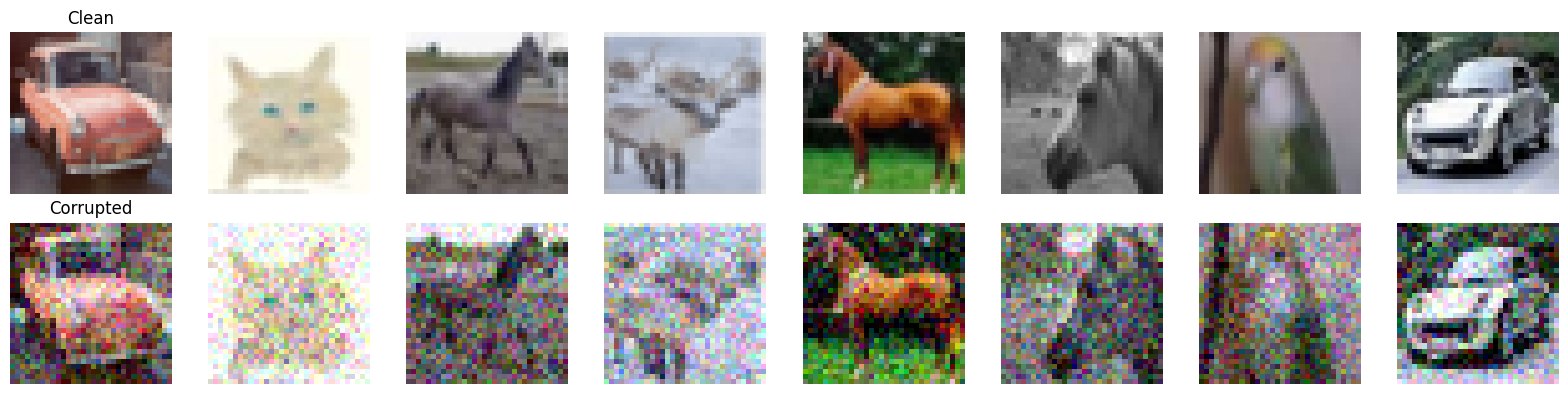

In [5]:
# Visual check: clean versus corrupted images

def show_clean_vs_corrupted(clean_loader, corrupt_loader, n=8):
    clean_x, _ = next(iter(clean_loader))
    corrupt_x, _ = next(iter(corrupt_loader))

    n = min(n, clean_x.shape[0])
    plt.figure(figsize=(2 * n, 4))

    for i in range(n):
        plt.subplot(2, n, i + 1)
        plt.imshow(clean_x[i].permute(1, 2, 0))
        plt.axis("off")
        if i == 0:
            plt.title("Clean")

        plt.subplot(2, n, n + i + 1)
        plt.imshow(corrupt_x[i].permute(1, 2, 0))
        plt.axis("off")
        if i == 0:
            plt.title("Corrupted")

    plt.tight_layout()
    plt.show()

show_clean_vs_corrupted(val_clean_loader, val_corrupt_loader, n=8)


## 3. Helper functions for evaluation

This project treats anomaly detection as a scoring problem. Each model produces an **anomaly score**, where a higher value means the image is more likely to be corrupted/anomalous.

The main metric is **AUROC** because it evaluates ranking quality without requiring a fixed threshold.


In [6]:
def compute_detection_metrics(clean_scores, anomaly_scores, model_name):
    """Compute AUROC and return a result row."""
    y_true = np.concatenate([
        np.zeros(len(clean_scores), dtype=int),
        np.ones(len(anomaly_scores), dtype=int)
    ])
    y_score = np.concatenate([clean_scores, anomaly_scores])

    auroc_value = roc_auc_score(y_true, y_score)
    return {
        "model": model_name,
        "validation_auroc": auroc_value,
        "clean_score_mean": float(np.mean(clean_scores)),
        "anomaly_score_mean": float(np.mean(anomaly_scores))
    }


def plot_score_distribution(clean_scores, anomaly_scores, title):
    plt.figure(figsize=(7, 4))
    plt.hist(clean_scores, bins=40, alpha=0.6, density=True, label="Clean")
    plt.hist(anomaly_scores, bins=40, alpha=0.6, density=True, label="Corrupted / anomaly")
    plt.xlabel("Anomaly score")
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_roc_curve(clean_scores, anomaly_scores, title):
    y_true = np.concatenate([
        np.zeros(len(clean_scores), dtype=int),
        np.ones(len(anomaly_scores), dtype=int)
    ])
    y_score = np.concatenate([clean_scores, anomaly_scores])

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(5, 5))
    plt.plot(fpr, tpr, label=f"AUROC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


## 4. Feature generation for simple baseline models

Before using deep learning, the notebook creates simple numeric features from each image. These features provide an interpretable baseline and help verify that the corruption task is learnable.

Generated features include:

- RGB channel means
- RGB channel standard deviations
- RGB channel minimum values
- RGB channel maximum values
- High-frequency energy approximation


In [7]:
@torch.no_grad()
def image_stat_features_from_batch(x):
    """Create compact image statistics from a batch of images."""
    channel_mean = x.mean(dim=(2, 3))
    channel_std = x.std(dim=(2, 3))
    channel_min = x.amin(dim=(2, 3))
    channel_max = x.amax(dim=(2, 3))

    # Approximate high-frequency energy using the difference from a local average.
    pooled = F.avg_pool2d(x, kernel_size=3, stride=1, padding=1)
    high_freq_energy = (x - pooled).abs().mean(dim=(2, 3))

    features = torch.cat([
        channel_mean,
        channel_std,
        channel_min,
        channel_max,
        high_freq_energy
    ], dim=1)

    return features.cpu().numpy()


@torch.no_grad()
def collect_stat_features(loader):
    all_features = []
    for xb, _ in loader:
        all_features.append(image_stat_features_from_batch(xb))
    return np.vstack(all_features)


@torch.no_grad()
def collect_flattened_images(loader):
    all_vectors = []
    for xb, _ in loader:
        all_vectors.append(xb.view(xb.shape[0], -1).cpu().numpy())
    return np.vstack(all_vectors)


X_train_stats = collect_stat_features(train_clean_loader)
X_val_clean_stats = collect_stat_features(val_clean_loader)
X_val_corrupt_stats = collect_stat_features(val_corrupt_loader)

print("Statistical feature shape:", X_train_stats.shape)

X_train_flat = collect_flattened_images(train_clean_loader)
X_val_clean_flat = collect_flattened_images(val_clean_loader)
X_val_corrupt_flat = collect_flattened_images(val_corrupt_loader)

print("Flattened image feature shape:", X_train_flat.shape)


Statistical feature shape: (4000, 15)
Flattened image feature shape: (4000, 3072)


## 5. Baseline model 1: Random score baseline

This baseline should be close to AUROC = 0.50. It confirms that the evaluation code behaves as expected.


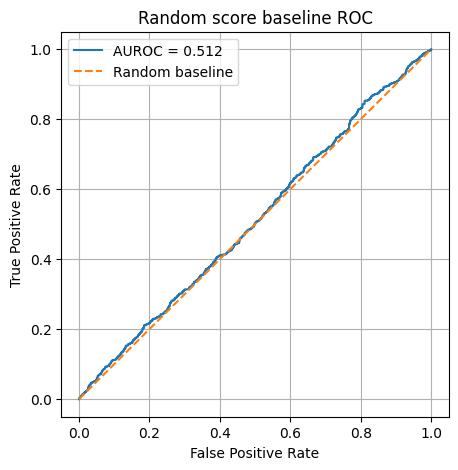

,model,validation_auroc,clean_score_mean,anomaly_score_mean
0,Random score baseline,0.511553,0.497178,0.508496


In [8]:
experiment_rows = []

rng = np.random.default_rng(SEED)
random_clean_scores = rng.random(len(val_clean_ds))
random_anomaly_scores = rng.random(len(val_corrupt_ds))

experiment_rows.append(
    compute_detection_metrics(
        random_clean_scores,
        random_anomaly_scores,
        "Random score baseline"
    )
)

plot_roc_curve(random_clean_scores, random_anomaly_scores, "Random score baseline ROC")
pd.DataFrame(experiment_rows)


## 6. Baseline model 2: Isolation Forest on image-statistic features

This is a simple unsupervised anomaly detection baseline. It learns the distribution of clean-image statistics, then assigns higher anomaly scores to images that look statistically unusual.


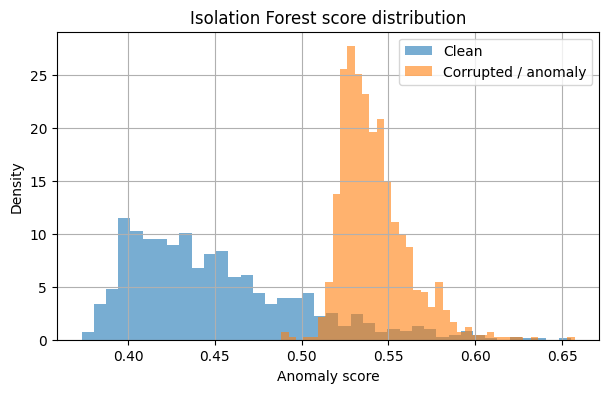

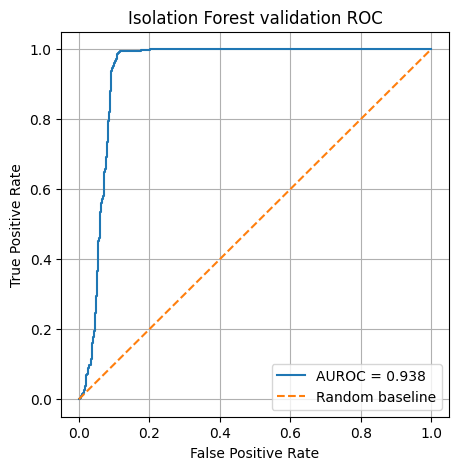

,model,validation_auroc,clean_score_mean,anomaly_score_mean
0,Random score baseline,0.511553,0.497178,0.508496
1,Isolation Forest on image-stat features,0.937605,0.449901,0.541735


In [9]:
iso_model = IsolationForest(
    n_estimators=100,
    contamination="auto",
    random_state=SEED
)

iso_model.fit(X_train_stats)

# sklearn score_samples: higher means more normal.
# We multiply by -1 so higher means more anomalous.
iso_clean_scores = -iso_model.score_samples(X_val_clean_stats)
iso_anomaly_scores = -iso_model.score_samples(X_val_corrupt_stats)

experiment_rows.append(
    compute_detection_metrics(
        iso_clean_scores,
        iso_anomaly_scores,
        "Isolation Forest on image-stat features"
    )
)

plot_score_distribution(
    iso_clean_scores,
    iso_anomaly_scores,
    "Isolation Forest score distribution"
)

plot_roc_curve(
    iso_clean_scores,
    iso_anomaly_scores,
    "Isolation Forest validation ROC"
)

pd.DataFrame(experiment_rows)


## 7. Baseline model 3: PCA reconstruction error

PCA is a stronger baseline because it learns a low-dimensional representation of clean images. An image is scored as anomalous when its PCA reconstruction error is high.


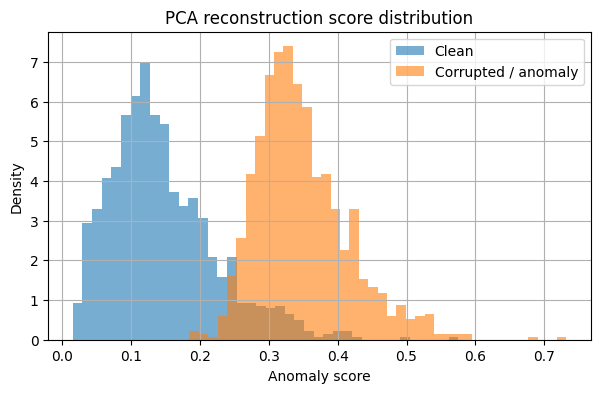

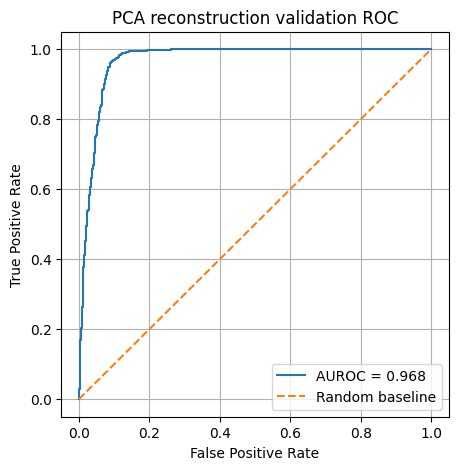

,model,validation_auroc,clean_score_mean,anomaly_score_mean
0,Random score baseline,0.511553,0.497178,0.508496
1,Isolation Forest on image-stat features,0.937605,0.449901,0.541735
2,PCA reconstruction baseline,0.967747,0.145703,0.348626


In [10]:
n_components = min(64, X_train_flat.shape[0] - 1, X_train_flat.shape[1])

scaler = StandardScaler()
X_train_flat_scaled = scaler.fit_transform(X_train_flat)

pca_model = PCA(n_components=n_components, random_state=SEED)
pca_model.fit(X_train_flat_scaled)

def pca_reconstruction_scores(X_flat):
    X_scaled = scaler.transform(X_flat)
    X_reduced = pca_model.transform(X_scaled)
    X_reconstructed = pca_model.inverse_transform(X_reduced)
    return np.mean((X_scaled - X_reconstructed) ** 2, axis=1)

pca_clean_scores = pca_reconstruction_scores(X_val_clean_flat)
pca_anomaly_scores = pca_reconstruction_scores(X_val_corrupt_flat)

experiment_rows.append(
    compute_detection_metrics(
        pca_clean_scores,
        pca_anomaly_scores,
        "PCA reconstruction baseline"
    )
)

plot_score_distribution(
    pca_clean_scores,
    pca_anomaly_scores,
    "PCA reconstruction score distribution"
)

plot_roc_curve(
    pca_clean_scores,
    pca_anomaly_scores,
    "PCA reconstruction validation ROC"
)

pd.DataFrame(experiment_rows)


## 8. More complex model: Convolutional Autoencoder

The convolutional autoencoder is the main baseline model for the project. It is trained on clean images and uses reconstruction error as the anomaly score.

The assumption is: if the model learns clean-image structure, corrupted images should produce higher reconstruction errors.


In [11]:
class ConvAutoencoder(nn.Module):
    """Small convolutional autoencoder for 32x32 RGB images."""

    def __init__(self, latent_channels=64):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 16 x 16 x 16

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 32 x 8 x 8

            nn.Conv2d(32, latent_channels, kernel_size=3, padding=1),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_channels, 32, kernel_size=2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2),
            nn.ReLU(),

            nn.Conv2d(16, 3, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)


@torch.no_grad()
def reconstruction_scores(model, loader, device=DEVICE):
    """Return per-image reconstruction MSE scores."""
    model.eval()
    scores = []

    for xb, _ in loader:
        xb = xb.to(device)
        recon = model(xb)
        batch_scores = F.mse_loss(recon, xb, reduction="none").mean(dim=(1, 2, 3))
        scores.append(batch_scores.detach().cpu().numpy())

    return np.concatenate(scores)


@torch.no_grad()
def reconstruction_loss(model, loader, device=DEVICE):
    """Average reconstruction loss over a loader."""
    model.eval()
    losses = []

    for xb, _ in loader:
        xb = xb.to(device)
        recon = model(xb)
        loss = F.mse_loss(recon, xb)
        losses.append(loss.item())

    return float(np.mean(losses))


def train_autoencoder(model, train_loader, val_loader, epochs=3, lr=1e-3, denoising=False):
    """Train either a standard or denoising autoencoder."""
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": []}

    best_val_loss = float("inf")
    best_state = None

    denoise_types = ["gaussian_noise", "salt_pepper", "brightness", "cutout"]

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []

        for xb, _ in tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}", leave=False):
            xb = xb.to(DEVICE)

            if denoising:
                chosen_type = random.choice(denoise_types)
                chosen_severity = random.choice([1, 2, 3])
                model_input = corrupt_batch(xb, chosen_type, chosen_severity)
                target = xb
            else:
                model_input = xb
                target = xb

            optimizer.zero_grad()
            recon = model(model_input)
            loss = F.mse_loss(recon, target)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        val_loss = reconstruction_loss(model, val_loader, device=DEVICE)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(f"Epoch {epoch:02d}: train_loss={train_loss:.5f}, val_loss={val_loss:.5f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history


def plot_training_history(history, title):
    plt.figure(figsize=(7, 4))
    plt.plot(history["train_loss"], marker="o", label="Train loss")
    plt.plot(history["val_loss"], marker="o", label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


Epoch 1/3:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 01: train_loss=0.05852, val_loss=0.03692


Epoch 2/3:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 02: train_loss=0.02531, val_loss=0.02124


Epoch 3/3:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 03: train_loss=0.01971, val_loss=0.01843


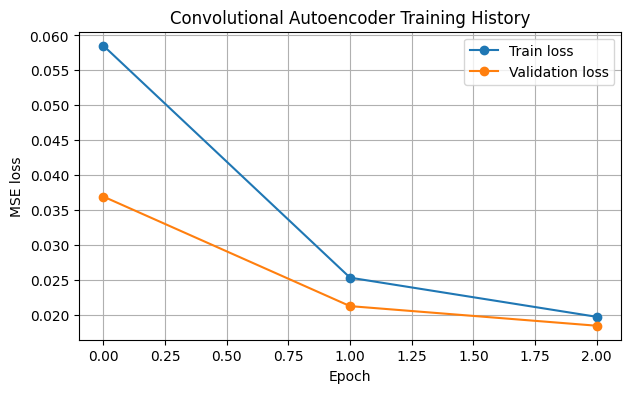

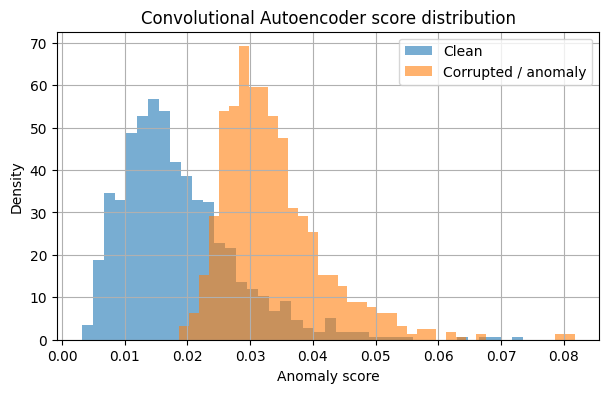

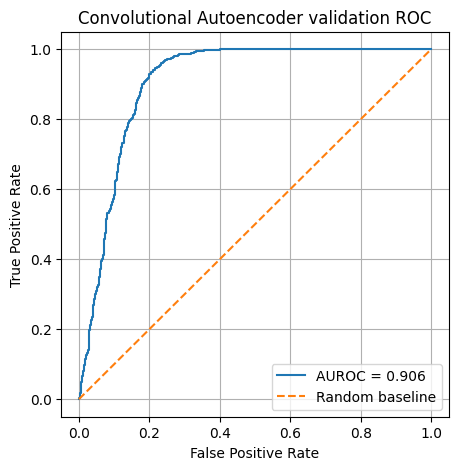

,model,validation_auroc,clean_score_mean,anomaly_score_mean
0,Random score baseline,0.511553,0.497178,0.508496
1,Isolation Forest on image-stat features,0.937605,0.449901,0.541735
2,PCA reconstruction baseline,0.967747,0.145703,0.348626
3,Convolutional Autoencoder,0.906125,0.018438,0.033616


In [12]:
# Train standard convolutional autoencoder

cae_model = ConvAutoencoder(latent_channels=64)

cae_model, cae_history = train_autoencoder(
    cae_model,
    train_clean_loader,
    val_clean_loader,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    denoising=False
)

plot_training_history(cae_history, "Convolutional Autoencoder Training History")

cae_clean_scores = reconstruction_scores(cae_model, val_clean_loader)
cae_anomaly_scores = reconstruction_scores(cae_model, val_corrupt_loader)

experiment_rows.append(
    compute_detection_metrics(
        cae_clean_scores,
        cae_anomaly_scores,
        "Convolutional Autoencoder"
    )
)

plot_score_distribution(
    cae_clean_scores,
    cae_anomaly_scores,
    "Convolutional Autoencoder score distribution"
)

plot_roc_curve(
    cae_clean_scores,
    cae_anomaly_scores,
    "Convolutional Autoencoder validation ROC"
)

pd.DataFrame(experiment_rows)


## 9. More complex model: Denoising Autoencoder

The denoising autoencoder is trained to reconstruct clean images from corrupted inputs. This may improve robustness because the model learns the difference between natural clean images and degraded images.


Epoch 1/3:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 01: train_loss=0.05956, val_loss=0.04500


Epoch 2/3:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 02: train_loss=0.04120, val_loss=0.02912


Epoch 3/3:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 03: train_loss=0.03120, val_loss=0.02906


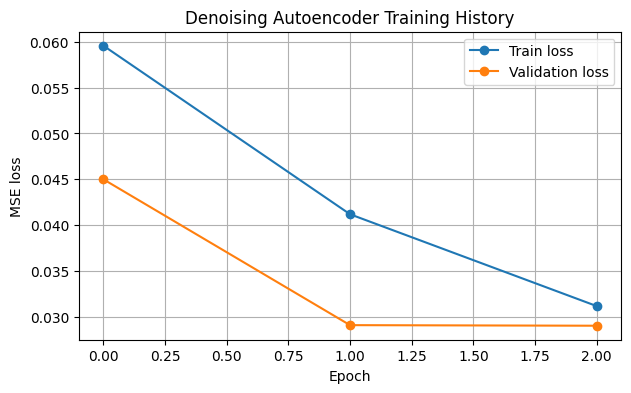

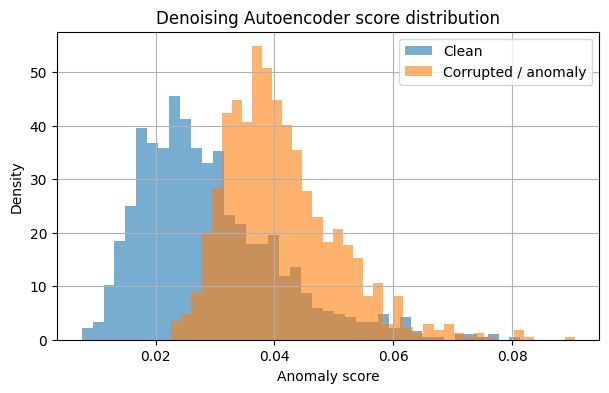

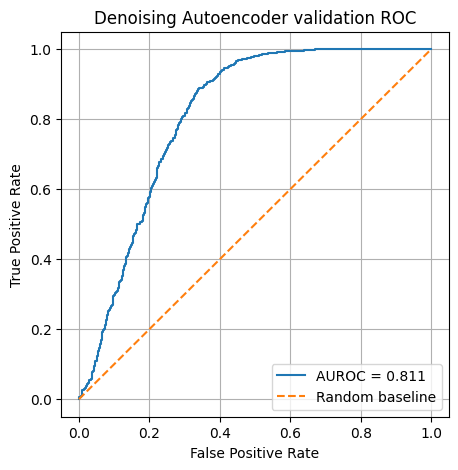

,model,validation_auroc,clean_score_mean,anomaly_score_mean
0,Random score baseline,0.511553,0.497178,0.508496
1,Isolation Forest on image-stat features,0.937605,0.449901,0.541735
2,PCA reconstruction baseline,0.967747,0.145703,0.348626
3,Convolutional Autoencoder,0.906125,0.018438,0.033616
4,Denoising Autoencoder,0.810604,0.029080,0.041141


In [13]:
# Train denoising autoencoder

dae_model = ConvAutoencoder(latent_channels=64)

dae_model, dae_history = train_autoencoder(
    dae_model,
    train_clean_loader,
    val_clean_loader,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    denoising=True
)

plot_training_history(dae_history, "Denoising Autoencoder Training History")

dae_clean_scores = reconstruction_scores(dae_model, val_clean_loader)
dae_anomaly_scores = reconstruction_scores(dae_model, val_corrupt_loader)

experiment_rows.append(
    compute_detection_metrics(
        dae_clean_scores,
        dae_anomaly_scores,
        "Denoising Autoencoder"
    )
)

plot_score_distribution(
    dae_clean_scores,
    dae_anomaly_scores,
    "Denoising Autoencoder score distribution"
)

plot_roc_curve(
    dae_clean_scores,
    dae_anomaly_scores,
    "Denoising Autoencoder validation ROC"
)

pd.DataFrame(experiment_rows)


## 10. Validation comparison: simple to complex

The table below compares all models on the validation split. The final test split has not been used yet.


In [14]:
results_df = pd.DataFrame(experiment_rows).sort_values("validation_auroc", ascending=False)
results_df


,model,validation_auroc,clean_score_mean,anomaly_score_mean
2,PCA reconstruction baseline,0.967747,0.145703,0.348626
1,Isolation Forest on image-stat features,0.937605,0.449901,0.541735
3,Convolutional Autoencoder,0.906125,0.018438,0.033616
4,Denoising Autoencoder,0.810604,0.029080,0.041141
0,Random score baseline,0.511553,0.497178,0.508496


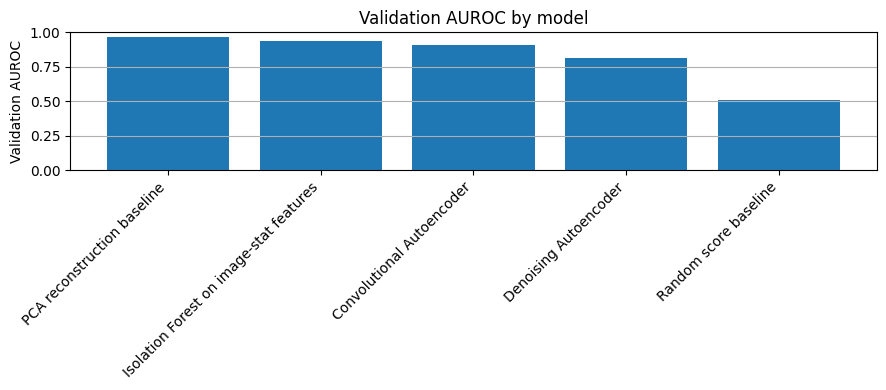

Best validation model: PCA reconstruction baseline


In [15]:
plt.figure(figsize=(9, 4))
plt.bar(results_df["model"], results_df["validation_auroc"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Validation AUROC")
plt.title("Validation AUROC by model")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]["model"]
print("Best validation model:", best_model_name)


## 11. Final held-out test evaluation

Only after the validation comparison do we evaluate on the final held-out test set. This keeps the test set from influencing model exploration.


In [16]:
# Collect final test features for simple baselines.
# This section intentionally runs only after the validation comparison.

X_test_clean_stats = collect_stat_features(test_clean_loader)
X_test_corrupt_stats = collect_stat_features(test_corrupt_loader)

X_test_clean_flat = collect_flattened_images(test_clean_loader)
X_test_corrupt_flat = collect_flattened_images(test_corrupt_loader)

final_rows = []

# Random baseline on test
rng = np.random.default_rng(SEED + 1)
final_rows.append(
    {
        "model": "Random score baseline",
        "final_test_auroc": roc_auc_score(
            np.r_[np.zeros(len(test_clean_ds)), np.ones(len(test_corrupt_ds))],
            np.r_[rng.random(len(test_clean_ds)), rng.random(len(test_corrupt_ds))]
        )
    }
)

# Isolation Forest on test
final_rows.append(
    {
        "model": "Isolation Forest on image-stat features",
        "final_test_auroc": roc_auc_score(
            np.r_[np.zeros(len(test_clean_ds)), np.ones(len(test_corrupt_ds))],
            np.r_[
                -iso_model.score_samples(X_test_clean_stats),
                -iso_model.score_samples(X_test_corrupt_stats)
            ]
        )
    }
)

# PCA reconstruction on test
final_rows.append(
    {
        "model": "PCA reconstruction baseline",
        "final_test_auroc": roc_auc_score(
            np.r_[np.zeros(len(test_clean_ds)), np.ones(len(test_corrupt_ds))],
            np.r_[
                pca_reconstruction_scores(X_test_clean_flat),
                pca_reconstruction_scores(X_test_corrupt_flat)
            ]
        )
    }
)

# Convolutional autoencoder on test
final_rows.append(
    {
        "model": "Convolutional Autoencoder",
        "final_test_auroc": roc_auc_score(
            np.r_[np.zeros(len(test_clean_ds)), np.ones(len(test_corrupt_ds))],
            np.r_[
                reconstruction_scores(cae_model, test_clean_loader),
                reconstruction_scores(cae_model, test_corrupt_loader)
            ]
        )
    }
)

# Denoising autoencoder on test
final_rows.append(
    {
        "model": "Denoising Autoencoder",
        "final_test_auroc": roc_auc_score(
            np.r_[np.zeros(len(test_clean_ds)), np.ones(len(test_corrupt_ds))],
            np.r_[
                reconstruction_scores(dae_model, test_clean_loader),
                reconstruction_scores(dae_model, test_corrupt_loader)
            ]
        )
    }
)

final_results_df = pd.DataFrame(final_rows).sort_values("final_test_auroc", ascending=False)
final_results_df


,model,final_test_auroc
2,PCA reconstruction baseline,0.977157
1,Isolation Forest on image-stat features,0.930347
3,Convolutional Autoencoder,0.913888
4,Denoising Autoencoder,0.828052
0,Random score baseline,0.514070


## 12. Robustness sweep across corruption types and severity levels

This section explores the research question: **Which corruption types and severity levels degrade anomaly detection performance most?**

For this first implementation, the sweep uses the denoising autoencoder because it is the more robust model candidate. In the final project, this can be repeated for all models.


In [17]:
corruption_types = ["gaussian_noise", "salt_pepper", "gaussian_blur", "brightness", "cutout"]
severity_levels = [1, 3, 5]

# Use the stronger candidate for the first robustness sweep.
# This can be changed based on validation results.
sweep_model = dae_model
sweep_model_name = "Denoising Autoencoder"

clean_reference_scores = reconstruction_scores(sweep_model, test_clean_loader)

sweep_rows = []

for corr_type in corruption_types:
    for sev in severity_levels:
        corr_ds = ImageSubsetWithOptionalCorruption(
            base_test_full,
            test_indices,
            corruption_type=corr_type,
            severity=sev
        )
        corr_loader = make_loader(corr_ds, shuffle=False)

        corr_scores = reconstruction_scores(sweep_model, corr_loader)
        auroc_value = roc_auc_score(
            np.r_[np.zeros(len(clean_reference_scores)), np.ones(len(corr_scores))],
            np.r_[clean_reference_scores, corr_scores]
        )

        sweep_rows.append({
            "model": sweep_model_name,
            "corruption_type": corr_type,
            "severity": sev,
            "auroc": auroc_value,
            "clean_score_mean": float(np.mean(clean_reference_scores)),
            "corrupt_score_mean": float(np.mean(corr_scores))
        })

sweep_df = pd.DataFrame(sweep_rows)
sweep_df


,model,corruption_type,severity,auroc,clean_score_mean,corrupt_score_mean
0,Denoising Autoencoder,gaussian_noise,1,0.544457,0.028605,0.029970
1,Denoising Autoencoder,gaussian_noise,3,0.827693,0.028605,0.040939
2,Denoising Autoencoder,gaussian_noise,5,0.974951,0.028605,0.060512
3,Denoising Autoencoder,salt_pepper,1,0.659314,0.028605,0.034158
4,Denoising Autoencoder,salt_pepper,3,0.876984,0.028605,0.045436
5,Denoising Autoencoder,salt_pepper,5,0.958161,0.028605,0.056691
6,Denoising Autoencoder,gaussian_blur,1,0.309910,0.028605,0.022167
7,Denoising Autoencoder,gaussian_blur,3,0.185025,0.028605,0.017612
8,Denoising Autoencoder,gaussian_blur,5,0.129372,0.028605,0.015125
9,Denoising Autoencoder,brightness,1,0.654817,0.028605,0.034913


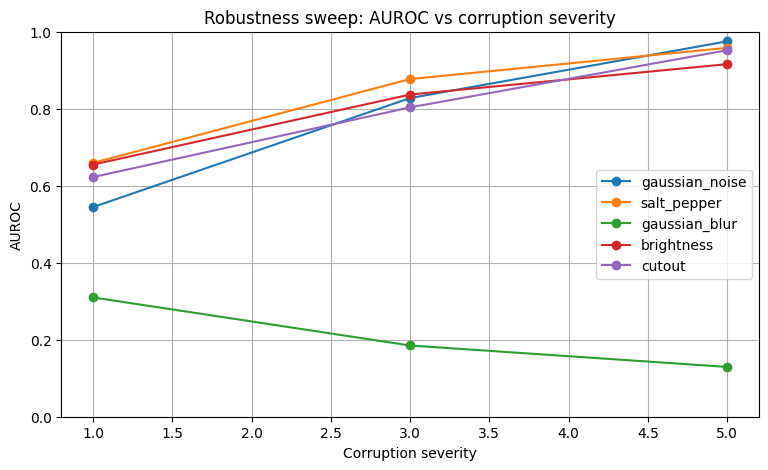

In [18]:
plt.figure(figsize=(9, 5))

for corr_type in corruption_types:
    subset = sweep_df[sweep_df["corruption_type"] == corr_type]
    plt.plot(subset["severity"], subset["auroc"], marker="o", label=corr_type)

plt.xlabel("Corruption severity")
plt.ylabel("AUROC")
plt.title("Robustness sweep: AUROC vs corruption severity")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()


## 13. Save initial project artifacts

This saves model weights and result tables from the initial workflow. These files can be included in the final project repository or report.


In [19]:
# Save model checkpoints and result tables

torch.save(cae_model.state_dict(), "results/convolutional_autoencoder_initial.pth")
torch.save(dae_model.state_dict(), "results/denoising_autoencoder_initial.pth")

results_df.to_csv("results/validation_model_comparison.csv", index=False)
final_results_df.to_csv("results/final_test_model_comparison.csv", index=False)
sweep_df.to_csv("results/robustness_sweep_initial.csv", index=False)

print("Saved:")
print("- results/convolutional_autoencoder_initial.pth")
print("- results/denoising_autoencoder_initial.pth")
print("- results/validation_model_comparison.csv")
print("- results/final_test_model_comparison.csv")
print("- results/robustness_sweep_initial.csv")


Saved:
- results/convolutional_autoencoder_initial.pth
- results/denoising_autoencoder_initial.pth
- results/validation_model_comparison.csv
- results/final_test_model_comparison.csv
- results/robustness_sweep_initial.csv


## 14. Initial conclusions and next steps

### What has been implemented

- CIFAR-10 data loading with a fallback option for code execution.
- Reproducible train, validation, and final test split.
- Feature generation through controlled image corruptions.
- Simple statistical features and flattened image features.
- Baseline models:
  - Random score baseline
  - Isolation Forest on image-statistic features
  - PCA reconstruction error baseline
- More complex models:
  - Convolutional Autoencoder
  - Denoising Autoencoder
- AUROC-based validation comparison.
- Final held-out test evaluation.
- Robustness sweep across corruption types and severity levels.

### What remains for the final project

- Increase training set size and number of epochs.
- Add early stopping patience and better checkpoint management.
- Tune latent dimension, learning rate, and batch size.
- Add additional corruption types or use CIFAR-10-C if available.
- Compare thresholds using false positive and false negative rates.
- Add a Variational Autoencoder extension if time allows.
- Write a final interpretation connecting the results to robust anomaly detection in real-world settings.


# Improved Training

## Retraining with more data, more epochs, and early stopping

In [20]:
# Reload CIFAR-10 with larger training set
import copy

to_tensor = transforms.ToTensor()

full_train_ds = datasets.CIFAR10(
    root=DATA_ROOT, train=True, download=False, transform=to_tensor
)
full_test_ds = datasets.CIFAR10(
    root=DATA_ROOT, train=False, download=False, transform=to_tensor
)

# Use 10,000 training images instead of 4,000
rng_improved = np.random.default_rng(SEED)
all_indices   = rng_improved.permutation(len(full_train_ds))

train_idx_imp = all_indices[:10000]
val_idx_imp   = all_indices[10000:11000]

train_imp_ds = torch.utils.data.Subset(full_train_ds, train_idx_imp)
val_imp_ds   = torch.utils.data.Subset(full_train_ds, val_idx_imp)

train_imp_loader = DataLoader(train_imp_ds, batch_size=128, shuffle=True)
val_imp_loader   = DataLoader(val_imp_ds,   batch_size=128, shuffle=False)

print(f"Improved training set : {len(train_imp_ds)} images")
print(f"Improved validation   : {len(val_imp_ds)} images")

Improved training set : 10000 images
Improved validation   : 1000 images


# Improved training function with early stopping

In [21]:
def train_autoencoder_improved(
    model, train_loader, val_loader,
    epochs=10, lr=1e-3, patience=3, denoising=False
):
    optimizer  = torch.optim.Adam(model.parameters(), lr=lr)
    criterion  = nn.MSELoss()
    history    = {"train_loss": [], "val_loss": []}
    
    best_val_loss  = float("inf")
    best_weights   = copy.deepcopy(model.state_dict())
    patience_count = 0

    for epoch in range(1, epochs + 1):
        # Training
        model.train()
        train_losses = []
        for x, _ in train_loader:
            x = x.to(DEVICE)
            x_input = corrupt_batch(x, severity=3) if denoising else x
            recon   = model(x_input)
            loss    = criterion(recon, x)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        # Validation
        model.eval()
        val_losses = []
        with torch.no_grad():
            for x, _ in val_loader:
                x = x.to(DEVICE)
                x_input = corrupt_batch(x, severity=3) if denoising else x
                recon   = model(x_input)
                loss    = criterion(recon, x)
                val_losses.append(loss.item())

        train_loss = np.mean(train_losses)
        val_loss   = np.mean(val_losses)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(f"Epoch {epoch:02d}/{epochs}: train={train_loss:.5f} val={val_loss:.5f}", end="")

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights  = copy.deepcopy(model.state_dict())
            patience_count = 0
            print(" -- best")
        else:
            patience_count += 1
            print(f" -- patience {patience_count}/{patience}")
            if patience_count >= patience:
                print("Early stopping triggered")
                break

    model.load_state_dict(best_weights)
    return model, history

print("Improved training function ready")

Improved training function ready


# Train improved autoencoder with latent dimension sweep

In [26]:
from sklearn.metrics import roc_auc_score

improved_results = []

for latent_ch in [32, 64, 128]:
    print(f"\nTraining with latent_channels={latent_ch}...")
    
    model_imp = ConvAutoencoder(latent_channels=latent_ch).to(DEVICE)
    model_imp, history_imp = train_autoencoder_improved(
        model_imp, train_imp_loader, val_imp_loader,
        epochs=10, lr=1e-3, patience=3, denoising=False
    )
    
    # Evaluate on original test set
    model_imp.eval()
    with torch.no_grad():
        imp_clean_scores   = reconstruction_scores(model_imp, test_clean_loader)
        imp_corrupt_scores = reconstruction_scores(model_imp, test_corrupt_loader)
    
    y_true  = np.concatenate([
        np.zeros(len(imp_clean_scores)),
        np.ones(len(imp_corrupt_scores))
    ])
    y_score = np.concatenate([imp_clean_scores, imp_corrupt_scores])
    auroc   = roc_auc_score(y_true, y_score)
    
    improved_results.append({
        "model": f"Improved CAE (latent_ch={latent_ch})",
        "latent_channels": latent_ch,
        "test_auroc": round(auroc, 6)
    })
    print(f"Test AUROC: {auroc:.4f}")

improved_df = pd.DataFrame(improved_results)
print("\nLatent dimension sweep results:")
print(improved_df)


Training with latent_channels=32...
Epoch 01/10: train=0.03806 val=0.01952 -- best
Epoch 02/10: train=0.01687 val=0.01613 -- best
Epoch 03/10: train=0.01501 val=0.01469 -- best
Epoch 04/10: train=0.01387 val=0.01345 -- best
Epoch 05/10: train=0.01244 val=0.01197 -- best
Epoch 06/10: train=0.01022 val=0.01074 -- best
Epoch 07/10: train=0.00878 val=0.00856 -- best
Epoch 08/10: train=0.00818 val=0.00806 -- best
Epoch 09/10: train=0.00768 val=0.00775 -- best
Epoch 10/10: train=0.00739 val=0.00749 -- best
Test AUROC: 0.9910

Training with latent_channels=64...
Epoch 01/10: train=0.03648 val=0.02006 -- best
Epoch 02/10: train=0.01681 val=0.01563 -- best
Epoch 03/10: train=0.01435 val=0.01384 -- best
Epoch 04/10: train=0.01278 val=0.01214 -- best
Epoch 05/10: train=0.01049 val=0.00979 -- best
Epoch 06/10: train=0.00862 val=0.00825 -- best
Epoch 07/10: train=0.00781 val=0.00767 -- best
Epoch 08/10: train=0.00725 val=0.00725 -- best
Epoch 09/10: train=0.00698 val=0.00715 -- best
Epoch 10/10: t

Full model comparison:
                                  model  test_auroc
            Improved CAE (latent_ch=64)    0.993881
           Improved CAE (latent_ch=128)    0.991977
            Improved CAE (latent_ch=32)    0.991038
            PCA reconstruction baseline    0.977157
Isolation Forest on image-stat features    0.930347
              Convolutional Autoencoder    0.913888
                  Denoising Autoencoder    0.828052
                  Random score baseline    0.514070


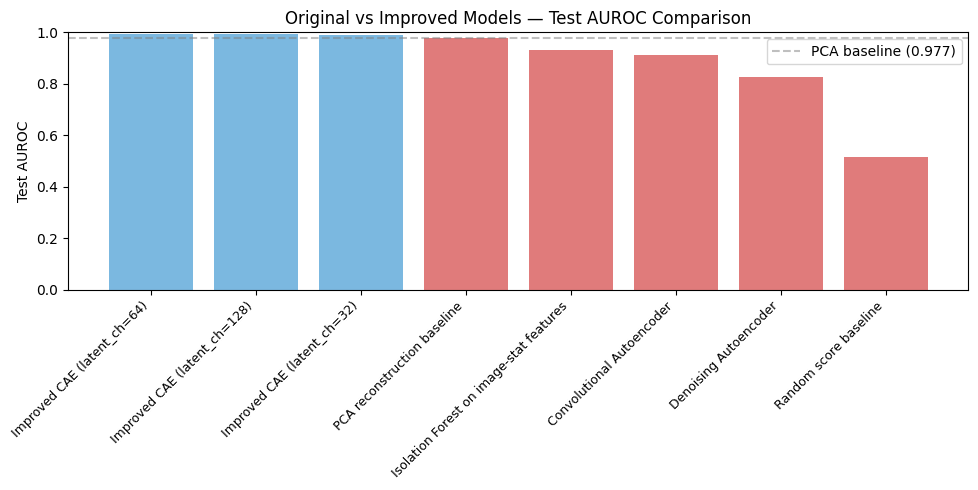

In [27]:
# Final comparison: original models vs improved
original_summary = final_results_df[["model", "final_test_auroc"]].copy()
original_summary.columns = ["model", "test_auroc"]

improved_summary = improved_df[["model", "test_auroc"]]

comparison_df = pd.concat([original_summary, improved_summary], ignore_index=True)
comparison_df = comparison_df.sort_values("test_auroc", ascending=False).reset_index(drop=True)

print("Full model comparison:")
print(comparison_df.to_string(index=False))

# Bar chart
plt.figure(figsize=(10, 5))
colors = ["#7bb8e0" if "Improved" in m else "#e07b7b" for m in comparison_df["model"]]
plt.bar(comparison_df["model"], comparison_df["test_auroc"], color=colors)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.ylabel("Test AUROC")
plt.title("Original vs Improved Models — Test AUROC Comparison")
plt.ylim(0, 1)
plt.axhline(y=0.977, color="gray", linestyle="--", alpha=0.5, label="PCA baseline (0.977)")
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
comparison_df.to_csv("results/improved_model_comparison.csv", index=False)
improved_df.to_csv("results/latent_dimension_sweep.csv", index=False)

# Save best improved model
best_latent = improved_df.loc[improved_df["test_auroc"].idxmax(), "latent_channels"]
print(f"Best latent_channels: {best_latent}")
print("Results saved to results/")

Best latent_channels: 64
Results saved to results/
